In [1]:
# some initialization stuff
%run ../init.py
%matplotlib inline
import scripts.helpers as hp

<IPython.core.display.Latex object>

# Numerical optimization

- Machine learning requires a lot of numerical computations
- The most common problem is to optimize some function given a set of constraints
- Analytical methods are hard to use in automatic approaches (although there are symbolic manipulation packages like Mathematica)
- Representation of and operations with real numbers (e.g. IEEE 754) cannot be done precisely with only a limited amount of memory
  - There is always some approximation error when represented in binary, e.g. $\sqrt{2}$ or $\frac{1}{3}$
- Algorithms that are theoretically correct may fail in practice
  - $\Rightarrow$ Minimize the accumulation of rounding errors
 

<div class="cite"> Nocedal J., Wright S.J.: Numerical Optimization. Springer 1999, ISBN 978-0-387-98793-4, pp. 1-634</div>

## Overflow and Underflow

- **Underflow** occurs when numbers processed by an algorithm are getting close to 0
  - E.g., while multiplying multiple small probability values
  - Rounding/precision errors might result in various issues like division by 0 or an operation returning `NaN`, such as $\log{0}$
- **Overflow** - also large numbers can cause NaN issues
- Functions using exponentiation must be *stabilized* against under- and overflow
  - For instance, the sigmoid function
$$\sigma(x) = \frac{e^x}{1+e^x}=\frac{1}{1+e^{-x}}$$
or softmax
$$\mathit{softmax}(\vec{x})=\frac{\exp{(x_i)}}{\sum_j \exp{(x_j)}}$$

- In case of softmax, consider the following input $\vec{x}^\top = [c,c,c,c]^\top$:
  - If $c$ is a very small constant, say $c=-\sqrt{2}\cdot 10^{10}$, then $e^c$ might underflow
  - However, the result of softmax is $[.25,.25,.25,.25]^\top$
  - Solution, center the input vector, i.e., evaluate on $\vec{y} = \vec{x} - \max(\vec{x})$, where $\max$ returns the maximum element of the vector
  - Evaluation result is the same!
  - The softmax function is **stabilized**
- Most of the DL packages stabilize the functions before their evaluation
  - Use functions provided by the packages whenever possible 
  - Stabilize custom functions  

# One-dimensional methods

- Remark: We consider only minimization problems of $f(\vec{x})$, since maximization can be solved by minimizing $-f(\vec{x})$
- One-dimensional methods are the simplest ones, however, have a number of limitations
- $f(x)$ is a *unimodal function* on an interval $[a,b]$:

$$ f(x)>f(x^*) \text{ for any } x \in [a,b], x \neq x^*$$

- $x^*$ is the value that minimizes $f(x)$ on $[a,b]$, i.e., $x^* = \arg\min f(x)$
- The function we minimize is called the **objective function**, aka criterion, cost function, loss function, or error function
  - Sometimes these terms are used interchangeably and sometimes they might have specific meanings 

## Bisection method

\begin{align*}
f(x) & \to \min \\
x \in \{x \in \mathbb{R} & \mid a\leq x\leq b\}
\end{align*}

- Given the precision of the computation $\epsilon$ 
- Algorithm
    1. Set $ x = (a + b)/2$
    2. if $b-a<\epsilon$ then return $x$
    3. Compute $x_1 = f(x-\epsilon/2)$ and $x_2 = f(x+\epsilon/2)$
    4. if $x_1 > x_2$, then $a=x$, else $b=x$
    5. goto 1


In [3]:
f1 = lambda x: 2*x**2 - x - 1

def bisection(f, a, b, e=1e-5):
    x = (a+b)/2
    if (b-a) < e: return x
    if f(x-e/2) > f(x+e/2): a=x
    else: b=x
    return bisection(f,a,b,e)

xm = bisection(f1, -4, 2)
print("x={}, f(x)={}".format(xm, f1(xm)))

x=0.2500009536743164, f(x)=-1.124999999998181


### Critical points 

- The **derivative** $f'(x)$ or $\frac{df}{dx}$ of the objective function $f(x)$ gives the slope of the function at the point $x$

$$f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$$

- Derivative specifies how does the function change given the change of its input

$$f(x+\eta) \approx f(x) + \eta f'(x)$$

In [4]:
sp = np.linspace(-.5,1,100)

def plot(f, h=0.25, x=0.25):
    if h==0 : h=1e-3
    plt.plot(sp, f(sp))
    plt.axline((x, f(x)),(x+h, f(x+h)))
    plt.plot(x, f(x), 'ro')
    plt.plot(x+h, f(x+h), 'ro')
    plt.show()

interactive(plot, f=fixed(f1), h=(-0.5,1,0.05), x=(-0.5,1,0.25))

interactive(children=(FloatSlider(value=0.25, description='h', max=1.0, min=-0.5, step=0.05), FloatSlider(valu…

- When $f'(x) = 0$ the derivative provides no information about the change
    - $x$ is a **critical** or a **stationary point**
-  Finding critical points in the example
    - $\frac{d}{dx}(2x^2-x-1) = 4x - 1$
    - $4x-1=0 \quad \Rightarrow x=1/4$ 

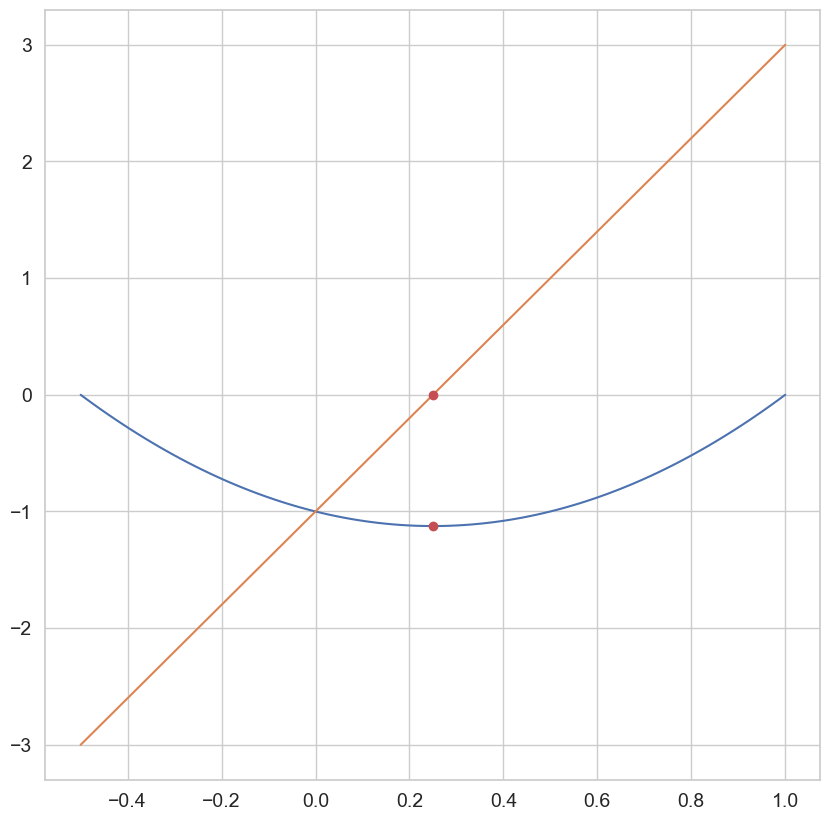

In [5]:
sp = np.linspace(-0.5,1,100)
df1 = lambda x: 4*x-1
plt.plot(sp, f1(sp))
plt.plot(sp, df1(sp))
plt.plot(1/4, 0, 'ro')
plt.plot(1/4, f1(1/4), 'ro');

- A critical point $x^*$ is a **global minimum** of $f(x^*)$ if for any $x\neq x^*$ $f(x)>f(x^*)$
- A critical point is a **local minimum** if any infinitesimal change $h$ of the argument results in a greater value of the function

x=0.6180353164672852, f(x)=-3.090169943737649


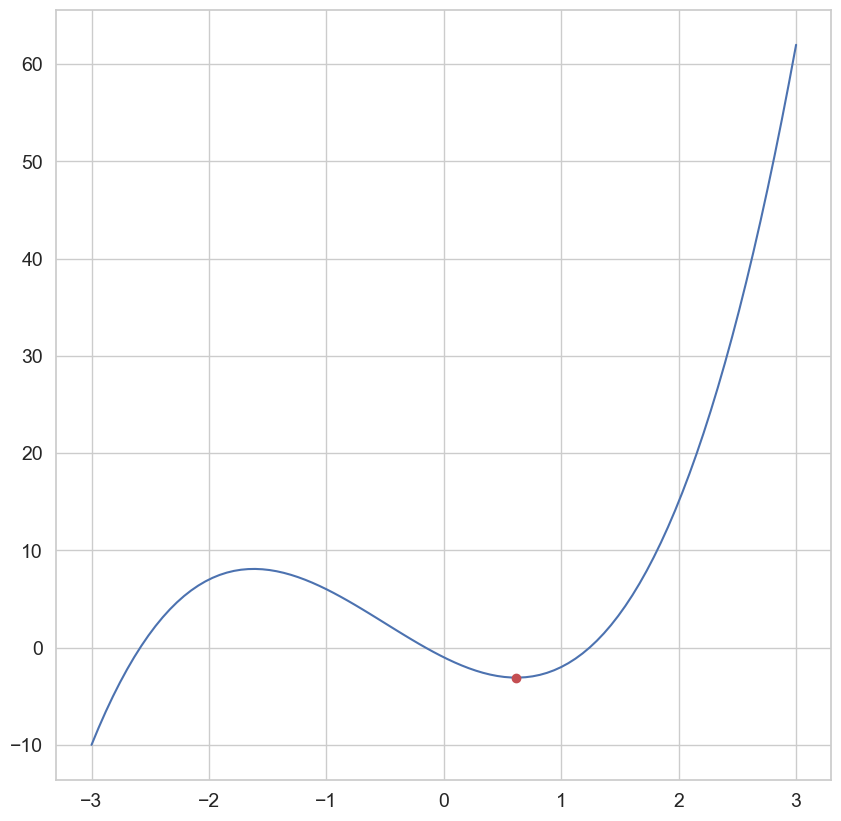

In [6]:
sp = np.linspace(-3,3,100)
f2 = lambda x: 2*x**3 + 3*x**2 - 6*x - 1
plt.plot(sp,f2(sp))

xm = bisection(f2, -3, 3)
print("x={}, f(x)={}".format(xm, f2(xm)))
plt.plot(xm, f2(xm), 'ro');

- Other critical points are **saddle points**, i.e., neither minima nor maxima
- Example:
  - let $f=2x^3$, then $\frac{df}{dx} = 6x^2$
  - critical point $x=0$

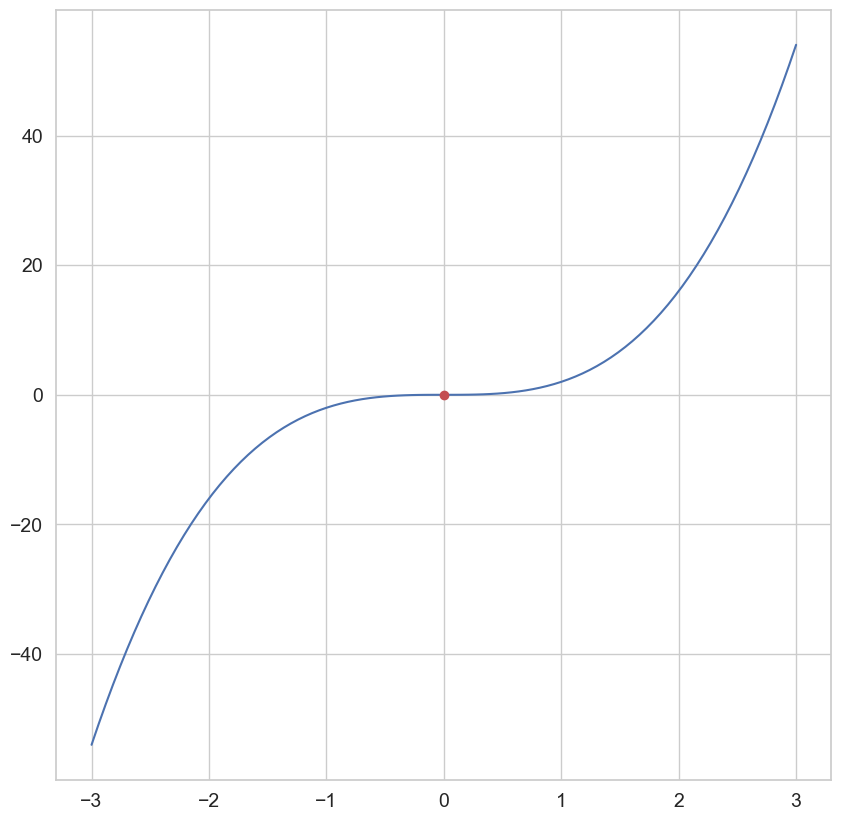

In [7]:
sp = np.linspace(-3,3,100)
f3 = lambda x: 2*x**3
plt.plot(sp,f3(sp))
plt.plot(0, f3(0), 'ro');

## Gradient descent

- We can use derivative to guide the optimization algorithm
- Consider an example for the sample function $f(x) = 2x^2-x-1$
  - Derivative of this function is $\frac{df}{dx}=4x-1$ exists in any point $x \in \mathbb{R}$
  - E.g., if $x=1$ then $f'(1) = 4-1 = 3$ so the rate of change in this point is $3$
  - The next point $x_n$ can be determined as $x_n = x - \eta \cdot f'(x)$ where $\eta$ is a scaling constant that determined the size of a step  

In [8]:
interactive(hp.g_idea, f=fixed(f1), df=fixed(df1), x=(-0.5,1,0.25), h=(0.01,0.4,0.01))

interactive(children=(FloatSlider(value=1.0, description='x', max=1.0, min=-0.5, step=0.25), FloatSlider(value…

- A simple search algorithm can iteratively:
  - determine the step using the gradient of the function in the current point as $x_n = x - \eta\cdot f'(x)$
  - check the termination condition, i.e., the length of the step $|x-x_n|<\epsilon$, where $\epsilon$ is the required precision

In [9]:
def grad(f, df, x, i = 1000, h=0.1, e=1e-6):
    trace = []
    for j in range(i):
        trace.append(float(x))
        x_n = x - h*df(x)
        if abs(x - x_n) < e: return trace
        x = x_n
    return trace

### Example 1

$$f_1(x) = 2x^2 - x - 1$$

$$\frac{df_1}{dx}=4x-1$$

In [10]:
@interact_manual(x=(1,4,0.5), i=(10,50,5), h=(0.01,.6,0.1))
def run_descent(x=3, i=10, h=0.1):
   trace = grad(f1, df1, x, i, h)
   xm = trace[-1]
   print("x={}, f(x)={}".format(xm, f1(xm)))
   hp.plot_trace(f1, trace)

interactive(children=(FloatSlider(value=3.0, description='x', max=4.0, min=1.0, step=0.5), IntSlider(value=10,…

### Example 2

$$f_2(x) = 2x^3 + 3x^2 - 6x - 1$$

$$\frac{df_2}{dx}=6x^2 +6x -6$$

In [11]:
df2 = lambda x: 6*x**2 + 6*x - 6

@interact_manual(x=( 1,3,0.5), i=(5,15,5), h=(0.01,.07,0.01))
def run_descent(x=3, i=10, h=0.02):
   trace = grad(f2, df2, x, i, h)
   xm = trace[-1]
   print("x={}, f(x)={}".format(xm, f2(xm)))
   hp.plot_trace(f2, trace)

interactive(children=(FloatSlider(value=3.0, description='x', max=3.0, min=1.0, step=0.5), IntSlider(value=10,…

<div class="myalert">This works only for functions with a single argument!</div>


## Partial derivatives

- Let us first introduce the notion of a gradient using a simple example
  - Consider a function $f(x,y) = xy$
  - Partial derivatives of this function $\frac{\partial f}{\partial x} = y$ and $\frac{\partial f}{\partial y} = x$
  - Given 
  $$\frac{\partial f}{\partial x} = \lim_{h\to 0}\frac{f(x+h,y)-f(x,y)}{h}$$
  the partial derivative indicates the rate of change of a function in an infinitely small region along $x$ axis
  - For example, if $x=2$ and $y=3$, i.e, $f(2,3)=6$, then $\frac{\partial f}{\partial x}=3$
  - That is, if we fix $y=3$ and increase $x$ by an infinitely small amount $h$, this will result in $f(x,y) = 3 f(x+h,y)$

## Gradient

<div class="myalert">Partial derivative of a function for each variable indicates the "sensitivity" of a function on its value </div>

- Examples:
    - For the sample function $f(x,y)$ the gradient is a vector of partial derivatives $\nabla f = \left[\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right] = [y,x]$
    - $f(x,y) = x + y$ the gradient vector $\nabla f = [1, 1]$
    - For $f(x,y) = \frac{1}{2}(x-y)^2$ we get $\nabla f = [x-y, y-x]$

- The gradient points directly "uphill" and the negative gradient points exactly "downhill"
- Minimize $f$ by moving in the direction of negative gradient: **gradient descent**
- Update rule
$$\vec{x}'=\vec{x} - \eta\nabla_\vec{x}f(\vec{x})$$
where $\eta$ determines the size of a step - **learning rate** in DL
- Selection of the learning rate can be done in different ways:
  - set to some small constant
  - evaluate $f(\vec{x}')$ for several values of $\epsilon$ and select the one that results in the smallest value of the objective function (aka line search)
- Gradient descent converges when every element of the gradient is 0 or very close to it
  - In some cases, as for the 1D case above, a critical point can be found by solving $\nabla_\vec{x}f(\vec{x})=0$
- Discrete variant of gradient descent is known as **hill climbing**

## Gradient descent: intuition

+ For a linear unit with two weights the hypothesis space is the plane $x,y$
+ The vertical axis indicates an error $f(x,y) = \frac{1}{2}(x-y)^2$
+ The gradient $\nabla f(r) = [x-y, y-x]$ is computed wrt. coordinates of red point $r = (x,y)$ (defined by sliders)
+ Blue point corresponds to the next step of the gradient descent $b = r - \eta\nabla f(r)$
+ Black line from the red to blue point indicates a direction in the plane $x, y$ resulting in the steepest descent along the error surface
+ $\eta$ defines the speed of the descent (corresponds to the learning rate in the perceptron rule)

In [12]:
class Descent:
    def __init__(self, xw, yw, f, dfdx, dfdy):
        self.f = f
        self.dfdx = dfdx
        self.dfdy = dfdy
        self.x = xw.value
        self.y = yw.value
        self.xw = xw
        self.yw = yw
    
    def step(self, x, y, h = 0.1):
        self.x -= h*self.dfdx(self.x, self.y)
        self.y -= h*self.dfdy(self.x, self.y)
        return self.x, self.y
    
    def update_widgets(self):
        self.xw.value = self.x
        self.yw.value = self.y
        
    def set_values(self, x, y):
        self.x = x
        self.y = y
        self.update_widgets()
    
    def plot(self, x, y, angle):
        hp.plot_grad(self.f, x, y, self.x, self.y, angle)

In [13]:
xw = widgets.FloatSlider(value=5,min=-10,max=10,step=0.1)
yw = widgets.FloatSlider(value=-7,min=-10,max=10,step=0.1)
hw = widgets.FloatSlider(value=0.01,min=0.01,max=0.5,step=0.01)
aw = widgets.IntSlider(value=40,min=0,max=360,step=20)

def on_button0_clicked(_):
    opt.set_values(5, -7)
    hw.value = 0.1
    aw.value = 60

button0 = widgets.Button(description="Reset")
button0.on_click(on_button0_clicked)

In [14]:
f = lambda x, y : (x-y)**2/2
dfdx = lambda x, y : x-y
dfdy = lambda x, y : y-x

opt = Descent(xw, yw, f, dfdx, dfdy)
display(button0)
interact_manual(hp.run_opt, opt=fixed(opt), x=xw, y=yw, h = hw, angle=aw);

Button(description='Reset', style=ButtonStyle())

interactive(children=(FloatSlider(value=5.0, description='x', max=10.0, min=-10.0), FloatSlider(value=-7.0, de…

### Linear Least Squares

- While fitting the linear model to the data in linear regression, our objective was to minimize 
$$\mathit{RSS}(\vec{w}) = \lVert \vec{X}\vec{w}-\vec{y}\rVert_2^2$$
where $\vec{X}$ are the observed features, $\vec{w}$ is a vector of weights we would like to find, and $\vec{y}$ is a set of target values
- The gradient in this case is

\begin{align*}
\nabla_\vec{w}f(\vec{w})=&\nabla_\vec{w}(\vec{X}\vec{w}-\vec{y})^\top(\vec{X}\vec{w}-\vec{y})=\\
=&\nabla_\vec{w}(\vec{w}^\top\vec{X}^\top\vec{X}\vec{w} -2\vec{w}^\top\vec{X}^\top\vec{y} + \vec{y}^\top\vec{y})= \\
=&2\vec{X}^\top\vec{X}\vec{w}-2\vec{X}^\top\vec{y}
\end{align*}

- The algorithm

\begin{align*}
\mathit{while} \text{  } & \lVert 2\vec{X}^\top\vec{X}\vec{w}-2\vec{X}^\top\vec{y} \rVert_2 > \epsilon \text{  } \mathit{do} \\
& \vec{w}' = \vec{w} - \eta \cdot 2 \left( \vec{X}^\top\vec{X}\vec{w}-\vec{X}^\top\vec{y} \right)
\end{align*}

In [15]:
f = lambda X, y, w: 2*torch.sub(torch.matmul(X.T,torch.matmul(X,w)), torch.matmul(X.T,y))

def lin_reg(X, y, w, e, h):
    old, out = 0, []
    for i in range(3000):
        grad = f(X,y,w)
        norm = torch.linalg.norm(grad, ord=2)
        w = torch.sub(w, h*grad)
        if abs(norm - old) < e: break
        old = norm
        out.append(norm)
    hp.plot_out(out)
    return w

### Initialization of weights

- Providing the algorithm with "good" initial weights is of a huge importance for the training process
    - Too small values might make it unnecessary long (vanishing gradients) or underflows
    - Too large - may lead to overflows during computations
    - Unfortunately, there is little knowledge on how to initialize weights for a given learning task
- The basic idea is to initialize weights with small random values to *break symmetries*
    - Assume, all weights are initialized with the same value, e.g., zero
    - The training procedure will have tendency to keep many equal (redundant) weights
    - Also such a learner will have issues with learning "special cases" 
- However, not all random values are good for an iterative optimization procedure

In [16]:
@interact(factor=(4,15,1))
def init_value(factor=5):
    y = torch.ones(100,100)
    for i in range(100):
        y = y @ (torch.randn(100,100)/factor) # matrix multiplication
    print("Mean: {}".format(y.mean()))

interactive(children=(IntSlider(value=5, description='factor', max=15, min=4), Output()), _dom_classes=('widge…

### Initialization of weights, cont'd

- How can we determine the correct factor?
- Multiplication of two $(n \times m)$ and $(m \times r)$ matrices requires the computation of $n\times r$ sums of $m$ products
- If we sample our matrices from a normal distribution $\mathcal{N}(0,1)$, then these $m$ products will also be distributed normally with $0$ mean and unit variance (standard deviation - $\sqrt{1}$)
- The sum will also have $0$ mean, but the variance is $m$ (standard deviation $\sqrt{m}$)
- We can rescale the values of a product matrix by the factor $1/\sqrt{m}$
    - Factor $10$ in the example above for $(100\times 100)$ matrices


## Advertisement example - simple model

- Assume a simple linear model in which the response variable $\rvar{y}$ depends only on one feature $\rvar{tv}$
\begin{equation*}
\rvar{y}=w_0 + w_1 \rvar{tv} + \epsilon
\end{equation*}
- $w_0$ determines the *intercept* and $w_1$ the slope of the line
- These parameters (coefficients) of the model are unknown and must be found
- $\epsilon$ is the random *error* term, which captures all we ignored in the linear model

\begin{equation*}
\rvar{sales} \approx w_0 + w_1 \rvar{TV}
\end{equation*}


*But is this model reasonable?*

In [17]:
adv = pd.read_csv('data/Advertising.csv', dtype=float)
adv = adv.drop(adv.columns[0], axis=1)
adv.head(5)
adv.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


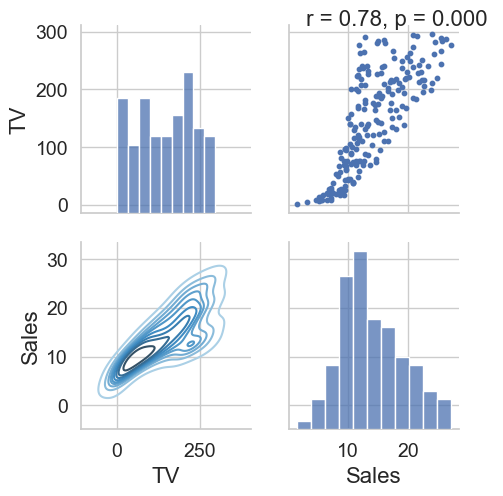

In [18]:
g = sns.PairGrid(adv[["TV","Sales"]])
g.map_upper(plt.scatter, s=10)
g.map_upper(hp.annotate)
g.map_diag(sns.histplot, kde=False)
g.map_lower(sns.kdeplot, cmap="Blues_d");

- *Given*: TV advertisement budget
- *Find*: a parameter vector $\vec{w}=[w_0, w_1]^\top$ of the function 
$$f(\mathit{tv} \mid \vec{w}) = w_0\cdot 1 + w_1\cdot\mathit{tv}$$
that approximates $\mathit{sales}$ as close as possible wrt. $\mathit{RSS}$

In [19]:
# prepare the data
X = torch.FloatTensor(adv.iloc[:,[0]].values)
# adding bias 
X = torch.cat((torch.ones(X.shape[0]).reshape(-1,1), X), axis=1)
y = torch.FloatTensor(adv.iloc[:,3].values).reshape(-1,1)

Finished optimization in 11 iterations with the grad 635.7293701171875


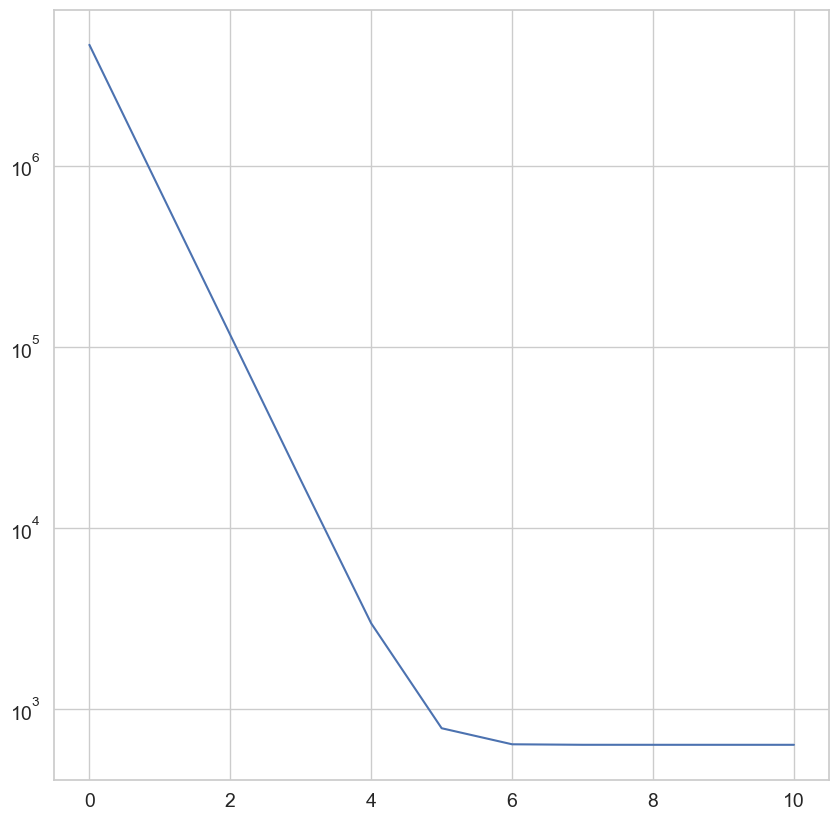

tensor([[0.7578],
        [0.0794]])


In [20]:
# generate the initial weights
w = torch.randn((X.shape[1],1))/math.sqrt(X.shape[1])

w = lin_reg(X, y, w, e = 5e-3, h = 1e-7)
print(w)

TSS = 1359.665 - total sum of squares - squared error of an average predictor
RSS = 932.772 - residual sum of squares
ESS = TSS - RSS =  1359.665 - 932.772 = 426.894 - explained sum of squares
MSE = 18.655 - mean squared error
MAE = 3.724 - mean absolute error


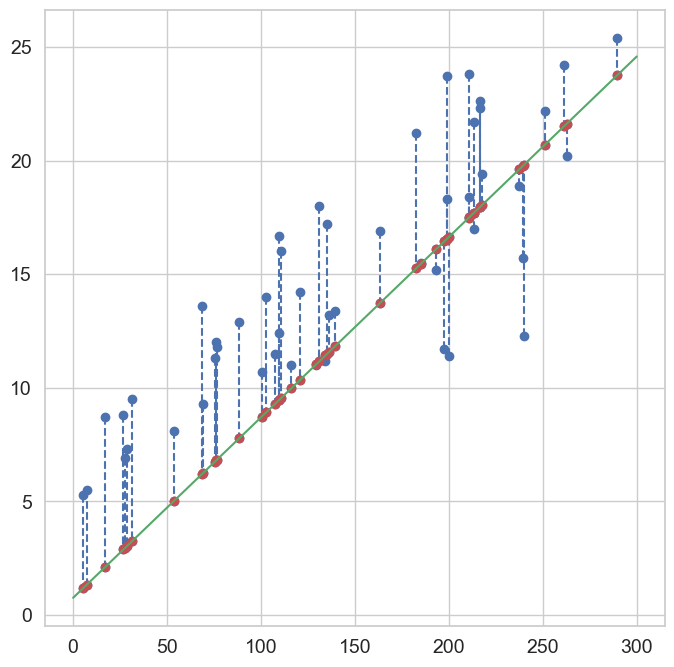

In [21]:
def predict(X):
    Xb = torch.cat((torch.ones(X.shape[0]).reshape(-1,1), X), axis=1)
    return torch.matmul(Xb,w)

tv = torch.FloatTensor(adv.TV[50:100].values)
sales = torch.FloatTensor(adv.Sales[50:100].values)
hp.plot_residuals(predict, tv, sales)

### Advertisement example - full model

- *Given*: TV, Radio, and Newspaper advertisement budgets
- *Find*: a parameter vector $\vec{w}=[w_0, w_1,w_2,w_3]^\top$ of the linear function 
$$f(\mathit{tv}, \mathit{radio}, \mathit{news} \mid \vec{w}) = w_0\cdot 1 + w_1\cdot\mathit{tv} + w_2\cdot\mathit{radio} + w_3\cdot \mathit{news}$$ 
that approximates $\mathit{sales}$ as close as possible wrt. $\mathit{RSS}$

In [22]:
adv = pd.read_csv('data/Advertising.csv')
adv = adv.drop(adv.columns[0], axis=1)

X = torch.FloatTensor(adv.iloc[:,[0,1,2]].values)
# adding bias 
X = torch.cat((torch.ones(X.shape[0]).reshape(-1,1), X), axis=1)
y = torch.FloatTensor(adv.iloc[:,3].values).reshape(-1,1)

Finished optimization in 1059 iterations with the grad 151.0243682861328


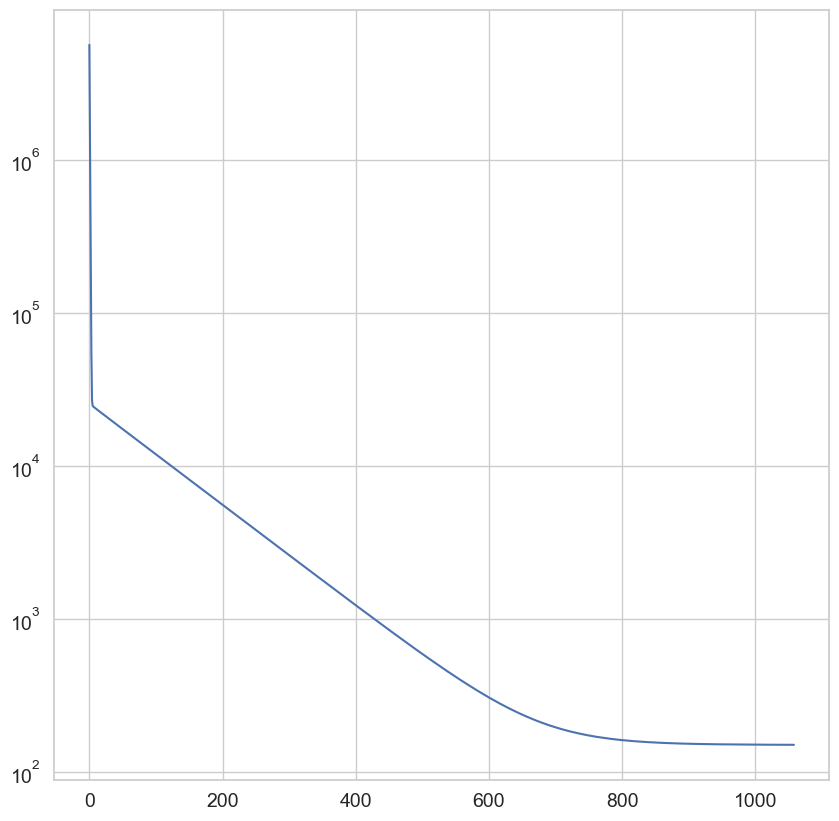

tensor([[0.3567],
        [0.0528],
        [0.2181],
        [0.0147]])

In [23]:
w = torch.randn((X.shape[1],1))/math.sqrt(X.shape[1])

lin_reg(X, y, w, e = 1e-3, h = 1e-7)

## Normalization

### Issues with data

- Data comprising features with values of different magnitudes might cause problems during the forward pass
    - Consider a sample ANN unit with weights $\vec{w} = [0, 0.3, 0.2]^\top$ and an input vector $\vec{x} = [1, 0.01, 100]^\top$
    - The output of this unit will be determined by solely by the last feature
    - Training can adapt the $w_3$, e.g., $w_3 = 0.00002$, to counteract this effect, but such disproportions will cause trouble at the beginning, e.g., loss values of the magnitude $10^6$ in the example above

- In general, given large disproportions in ranges of input variables, similar changes in weights might result in significant changes of the function output
    - Even rounding errors might cause significant influence on the results of the optimization algorithm

### Poor conditioning

- **Condition number** measures how much the result of a function can change given a small change in its arguments
  - In DL condition numbers are often considered from the perspective of solving a system of linear equations $\vec{X}\vec{w}=\vec{y}$
  - The condition number is defined to be the maximum ratio of the relative error in $\vec{w}$ to the relative error in $\vec{y}$
  - For instance, for linear equations, the condition number of the matrix $\vec{X} \in \mathbb{R}^{n\times n}$ determines how accurate the solution $\vec{x}$ will be after approximation 
  - If $\vec{X}$ is normal ($X^\top X =  X X^\top$), then it has an eigenvalue decomposition (spectral theorem) and the condition number can be defined as $$\max_{i,j}\left|\frac{\lambda_i}{\lambda_j}\right|$$
- Poor condition number (ill-conditioned problem) might trouble the selection of a good step size!

### Rescaling (normalization)

- **Standardization** assumes that the observations are sampled from the normal distribution $\mathcal{N}(\mu, \sigma^2)$
    - The feature values $\vec{x}$ are then rescaled using
    $$\vec{x}_s = \frac{\vec{x} - \mu}{\sigma}$$
    where $\vec{x}_s$ are scores with zero mean and unit variance
- **Min-Max** scaler ensures that the data ranges between the given $min$ and $max$ values
$$\vec{x}_s = \frac{\vec{x} - \text{min}(\vec{x})}{\text{max}(\vec{x}) - \text{min}(\vec{x})} \cdot (max - min) + min$$
- Many other rescaling methods can be used because of their properties:
    - Mean normalization, which is similar to standard scaler with $\sigma^2= \text{max}(\vec{x}) - \text{min}(\vec{x})$
    - Robust scaler that uses quartiles $Q_i$, i.e., $\mu=Q_2(\vec{x})$ and $\sigma^2 = Q_3(\vec{x})-Q_1(\vec{x})$

Finished optimization in 130 iterations with the grad 0.0015174346044659615


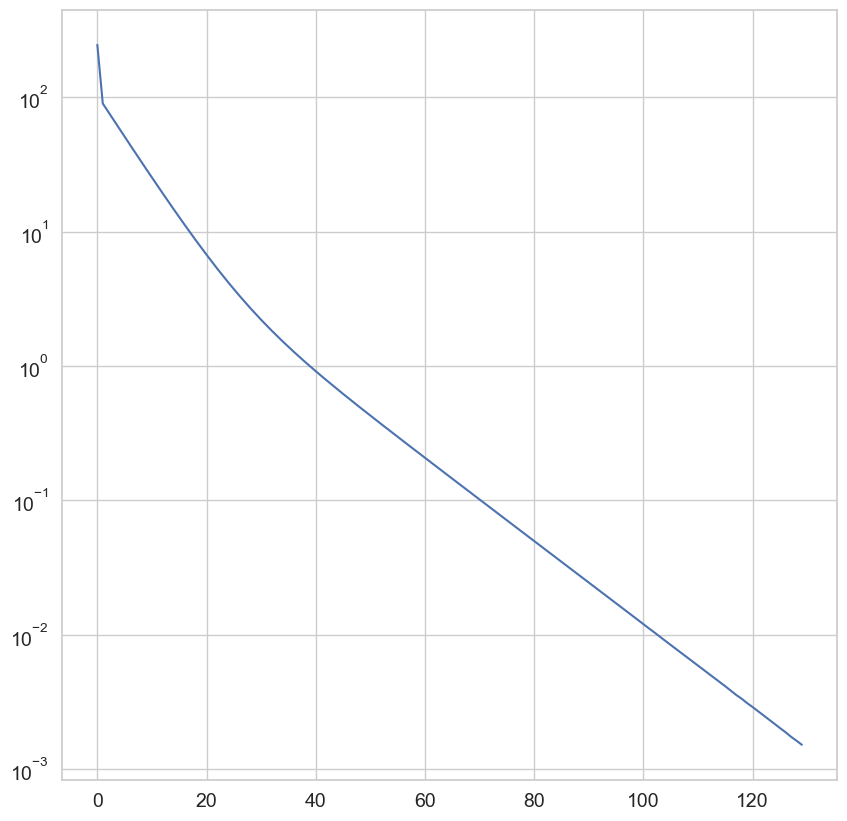

tensor([[ 0.5929],
        [ 0.3435],
        [-0.0950],
        [-0.4335]])

In [24]:
# standardize the data
Xs = (X - X.mean(dim=1, keepdim=True)) / X.std(dim=1, keepdim=True)
ys = (y - y.mean()) / y.std()

w = torch.randn((X.shape[1],1))/math.sqrt(X.shape[1])
lin_reg(Xs, ys, w, e = 1e-4, h = 1e-3)

## Stochastic GD (SGD)

- The loss function in the previous example (and many other functions) was computed as a sum over all available examples
- In practice, if the number of examples is large and the function is computationally hard, it might be quite costly to compute the gradient
  - Large training sets are necessary for good DL results
  - DL architectures are way more complex than a polynomial of $n$ arguments
- **Stochastic GD** approximates the gradient by considering only a subset of data at a time
$$\mathbb{E}_i \nabla f([\vec{X}]_i \mid \vec{w}) = \frac{1}{n} \sum_{i = 1}^n \nabla f([\vec{X}]_i \mid \vec{w}) = \nabla f(\vec{X} \mid \vec{w})$$
- **Minibatch** - is a subset of examples drawn uniformly from the training set
  - The size of a minibatch is usually much smaller than a dataset
  - Size is selected wrt. computational power available and is usually **not changed** as the number of training examples grows

### Batch normalization

- Similarly to the standardization of the input data, we can apply standardization to input or output values of hidden layers in a neural network
    - The idea is that by standardizing the values of one hidden layer we can simplify the training of the next layer (Ioffe and Szegedy, 2015)
    - Can prevent the *vanishing* and *exploding gradient* problems while training very deep networks
    - $\Rightarrow$ Rescaling must be done during training every time the values are updated
- A layer can be represents as a function $\vec{z} = h(\vec{x})$, where $\vec{x}$ are input and $\vec{z}$ are output values
- The approach for input values $\vec{x}$ of a feature $f$ provided by $K$ observations in a minibatch is defined as follows:
$$\vec{x}_s = \frac{\vec{x} - \mu}{\sqrt{\sigma^2 + \delta}}$$
where $\mu$ and $\sigma^2$ are computed over the batch, i.e., $i=1,\dots,K$, and $\delta$ is a small constant used to avoid numerical issues

<div class="cite">S. Ioffe, C. Szegedy. "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift", 2015, arXiv:1502.03167</div>

### Batch normalization, cont'd

- This kind of rescaling might limit the representation capability of a network
- Compensate with the rescaling of scores $$\vec{x}'_s = \gamma \vec{x}_s + \beta$$ where $\gamma$ and $\beta$ are learnable parameters of a *batch normalization* layer computed *during training*
- In some cases, during inference, the batches are not available $\to$ estimation of $\mu$ and $\sigma^2$ is not possible from one example
- Solution: compute moving averages of both parameters over all minibatches during training
$$\vec{p}^t = \alpha \vec{p}^{t-1} + (1-\alpha)\vec{p}$$ where $0 \geq \alpha \geq 1$
    - Both averages are not used during training
- We still do not know why batch normalization improves training results, but some studies suggest that it improves the smoothness of the loss function landscape


<div class="cite">S. Santurkar et al. "How does batch normalization help optimization?." Advances in Neural Information Processing Systems 31 (2018).</div>

### Layer normalization

- Dependency of the previous method on the batch size (parameter estimation) and computation strategies (splitting among GPUs)
- *Layer normalization* does the same but over all hidden units in a layer for each data sample separately
    - Given a data sample, e.g., output of neurons in the previous layer, $\mu$ and $\sigma^2$ are estimated as sums over all hidden units of the current layer
- Learnable parameters $\gamma$ and $\beta$ are trained similarly to the batch normalization
- For the inference, there is no need of any moving averages since the parameters $\mu$ and $\sigma^2$ can always be estimated for any hidden layer just as it was done during the training

### Shattered gradients

- Typically, the deeper is the architecture the better is the generalization performance
    - Careful initialization of the weights and biases, can help address the problem of vanishing or exploding gradients
    - However, even with batch normalization, it becomes increasingly difficult to train networks with a large number of layers
- Shattered gradients:
    - ReLU activation functions enable an exponential increase in the number of linear regions that the network can represent
    - However, they also result in the proliferation of discontinuities in the gradient of the error function
    

### Shattered gradients, cont'd

- Jacobian of networks with single input and output, showing network with 2 and 25 layers, and 51 layers with residual connections

<center>
    <img src="images/shattered_gradients.png" width="80%"/>
</center>

<div class="cite">Balduzzi, David, et al. "The shattered gradients problem: If resnets are the answer, then what is the question?." PMLR, 2017 </div>

### Residual connections

- Residual connections (He et al., 2015a), which are a particular form of skip-layer connections allow to improve the training performance of deep networks


<center>
    <img src="images/res_connections.svg" width="60%"/>
</center>

- It consists of a sequence of three layers of the form

$$
\begin{align}
\vec{z_1} &= F_1(\vec{x}) + \vec{x}\\
\vec{z_2} &= F_2(\vec{z}_1) + \vec{z}_1\\
\vec{y} &= F_3(\vec{z}_2) + \vec{z}_2
\end{align}
$$

### Residual connections, cont'd

- Expanded network comprises 3 subnetworks acting in parallel


<center>
    <img src="images/res_connections_full.svg" width="50%"/>
</center>

$$ \vec{y} = F_3(F_2(F_1(\vec{x}) + \vec{x}) + F_1(\vec{x}) + \vec{x}) + F_2(F_1(\vec{x}) + \vec{x}) + F_1(\vec{x}) + \vec{x} $$

# Selection of the learning rate

- Guessing a good learning rate is hard since the optimized function $ f: \mathbb{R}^n \to \mathbb{R}$ might have different sensitivity to changes of input values
    - Rescaling of the domain (observations) or learned weights $\vec{w}$    
- It can be shown that the learning rate must tend to 0 as the algorithm approaches to the optimum
    - Scheduling strategies to decay the learning rate


&nbsp;
<div class="cite">Yu. Nesterov, J.-Ph. Vial, Confidence level solutions for stochastic programming, Automatica 44(6), 2008, pp.1559-1568</div> 

## Iterative adjusting

- Different *scheduling strategies* can be used to set an appropriate learning rate during training 
- Selection from the vector $\vec{\eta}$ of constants at each iteration $t$
$$\eta_t = [\vec{\eta}]_i \text{ if } t_i \leq t \leq t_{i+1}$$
- Decay functions with an initial learning rate $\eta_0$:
    - Polynomial function $\eta_t = \eta_0 \cdot (\beta t + 1)^{-\alpha}$
    - Exponential decay $\eta_t = \eta_0 \cdot e^{-\lambda t}$


## Adaptive methods - Newton's method

- Given a function $ f: \mathbb{R}^n \to \mathbb{R}$, let us consider its Taylor expansion up to the second term at a point $ \boldsymbol{\epsilon}$ at which second derivative exists
$$f(\vec{x} + \boldsymbol{\epsilon}) = f(\vec{x}) + \boldsymbol{\epsilon}^\top \nabla f(\vec{x}) + \frac{1}{2} \boldsymbol{\epsilon}^\top \nabla^2 f(\vec{x}) \boldsymbol{\epsilon} + \mathcal{O}(\|\boldsymbol{\epsilon}\|^3)$$
- $\nabla^2 f(\vec{x})$ is an $n\times n$ matrix called Hessian and denoted as $\vec{H}$

### Hessian

- Directional second derivative tells *how well a gradient descent step might perform*
    - Second-order information allows the optimizer to be cautious whenever the curvature is large and to take longer steps whenever the objective function is flatter

$$\vec{H}={\begin{bmatrix}{\dfrac {\partial ^{2}f}{\partial x_{1}^{2}}}&{\dfrac {\partial ^{2}f}{\partial x_{1}\,\partial x_{2}}}&\cdots &{\dfrac {\partial ^{2}f}{\partial x_{1}\,\partial x_{n}}}\\[2.2ex]{\dfrac {\partial ^{2}f}{\partial x_{2}\,\partial x_{1}}}&{\dfrac {\partial ^{2}f}{\partial x_{2}^{2}}}&\cdots &{\dfrac {\partial ^{2}f}{\partial x_{2}\,\partial x_{n}}}\\[2.2ex]\vdots &\vdots &\ddots &\vdots \\[2.2ex]{\dfrac {\partial ^{2}f}{\partial x_{n}\,\partial x_{1}}}&{\dfrac {\partial ^{2}f}{\partial x_{n}\,\partial x_{2}}}&\cdots &{\dfrac {\partial ^{2}f}{\partial x_{n}^{2}}}\end{bmatrix}}$$

### Optimization

- The (local) minimum of $f$ satisfies $\nabla f = 0 $
- By taking a derivative wrt. $\boldsymbol{\epsilon}$ of
$f(\vec{x} + \boldsymbol{\epsilon}) \approx f(\vec{x}) + \boldsymbol{\epsilon}^\top \nabla f(\vec{x}) + \frac{1}{2} \boldsymbol{\epsilon}^\top \nabla^2 f(\vec{x}) \boldsymbol{\epsilon}$
- We get $\nabla f(\vec{x}) + \vec{H} \boldsymbol{\epsilon} = 0$ and, therefore, $\boldsymbol{\epsilon} = -\vec{H}^{-1} \nabla f(\vec{x})$
- Therefore the update rule $\vec{x}' = \vec{x} - \vec{H}^{-1} \nabla f(\vec{x})$

- For example, consider a function $f(\vec{x})=3x_0^2 + 5$ at a starting point $\vec{x}=[2]$:
    - $\nabla f(\vec{x}) = [6x]$ and $\vec{H} = [[6]]$
    - Hence, $\vec{\epsilon} = -\vec{H}^{-1} \nabla f(\vec{x}) = [- \frac{1}{6} 6x] = [-x]$
    - $\vec{x}' = \vec{x} + \vec{\epsilon} = [2] + [-2] = [0]$

## Practical variants

- Adding a learning rate might still be a good idea since in practice we mostly optimize non-convex functions 
$$x' = x - \eta \vec{H}^{-1} \nabla f(\vec{x})$$
- Storing and updating Hessian is very expensive, given a large number of optimization steps required for modern datasets
- *Preconditioning* focuses on the maintenance of the main diagonal of a Hessian
$$\vec{x} \leftarrow \vec{x} - \eta\; \diag{\vec{H}}^{-1} \nabla f(\vec{x})$$
- This method allows the algorithm to rescale components of the gradient by enabling different learning rate for each parameter

## Momentum

- SGD is sensitive to the slope of an optimized function in different dimensions
    - Consider $f(\vec{x}) = 0.1x_1^2+10x_2^2$
    - $\nabla f(\vec{x}) = [0.2x_1,20x_2]$ - steps along the $x_1$ dimension are small, whereas along $x_2$ are large
    - Even with a large learning rate the algorithm might not converge to the minimum $\vec{x}^*=[0,0]$ 

In [25]:
def on_button1_clicked(_):
    opt.set_values(5, -10)
    hw.value = 0.01
    aw.value = 40

button1 = widgets.Button(description="Reset")
button1.on_click(on_button1_clicked)

In [26]:
f = lambda x1, x2 : 0.1*x1**2 + 10*x2**2
dfdx = lambda x1, x2 : 0.2*x1
dfdy = lambda x1, x2 : 20*x2

display(button1)
opt1 = Descent(xw, yw, f, dfdx, dfdy)
interact_manual(hp.run_opt, opt=fixed(opt1), x=xw, y=yw, h = hw, angle=aw);

Button(description='Reset', style=ButtonStyle())

interactive(children=(FloatSlider(value=5.0, description='x', max=10.0, min=-10.0), FloatSlider(value=-7.0, de…

- Momentum (`pytorch` version), let $v_i$ denote the *velocity*, $\mu$ - the *momentum*, and $\eta$ - the learning rate


\begin{align*}
\vec{v}_t & = \mu\,\vec{v}_{t-1} + \nabla f(\vec{x})\\
\vec{x}_t & = \vec{x}_{t-1} - \eta \vec{v}_t
\end{align*}


- Allows to reduce the oscillations of SGD

In [27]:
class MDescent(Descent):
    v1 = 0
    v2 = 0
    mu = 0.5
    
    def step(self, x, y, h):
        self.v1 = self.mu * self.v1 + self.dfdx(x,y)
        self.v2 = self.mu * self.v2 + self.dfdy(x,y)
        self.x = self.x - h*self.v1
        self.y = self.y - h*self.v2
        return self.x, self.y
    
    def set_mu(self, mu):
        self.mu = mu

In [28]:
def on_button2_clicked(_):
    xw.value = 5
    yw.value = -10
    hw.value = 0.1
    aw.value = 40
    
button2 = widgets.Button(description="Reset")
button2.on_click(on_button2_clicked)

In [29]:
mopt = MDescent(xw, yw, f, dfdx, dfdy) 
display(button2)
interact_manual(hp.run_momentum, opt=fixed(mopt), x=xw, y=yw, h = hw, mu=(0,1,0.1), angle=aw);

Button(description='Reset', style=ButtonStyle())

interactive(children=(FloatSlider(value=5.0, description='x', max=10.0, min=-10.0), FloatSlider(value=-7.0, de…

## Example: Multivariate regression with Pytorch

- SDG for training a linear model with MSE, where $\vec{e}=\vec{y}-\hat{\vec{y}}$ and $n$ is the number of elements in $\vec{e}$ 

$$\mathit{MSE} = \frac{1}{n}\lVert\vec{e}\rVert^2_2$$

- *Linear* combination of features
    - Given an observation vector $[1, x_1, \cdots, x_n]$ of $n$ features including bias
    - And $[w_0, w_1, \cdots, w_n]$ parameters of the model 
    - Linear combination of its components wrt. parameters is $w_01 + w_1x_1 + \cdots + w_nx_n$ 


In [30]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self, X, y):
        self.x, self.y = X, y
        self.len=self.x.shape[0]
    def __getitem__(self,index):    
        return self.x[index],self.y[index]
    def __len__(self):
        return self.len
    
class LinReg(torch.nn.Module):
    def __init__(self, nfeatures):
        super(LinReg, self).__init__()
        self.linear = torch.nn.Linear(nfeatures, 1, bias=False) # we already have bias in X

    def forward(self, x):
        out = self.linear(x)
        return out

In [31]:
@interact_manual(epochs=(1,1000,10), batch_size=(1,X.shape[0],1), m=(.2,1,.2))
def train_lr(epochs=1000, batch_size = 200, m=.5):
    model = LinReg(Xs.shape[1])
    criterion = torch.nn.MSELoss() 
    opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=m)
    loader = DataLoader(dataset=Data(Xs, ys), batch_size=batch_size)

    out=[]
    for epoch in range(epochs):
        for x,y in loader:
            # reset optimizer
            opt.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            opt.step()
            out.append(loss.item())

    hp.plot_out(out)
    for p in model.parameters(): print(p)

interactive(children=(IntSlider(value=1000, description='epochs', max=1000, min=1, step=10), IntSlider(value=2…

### Schedule learning rate updates

- To get good accuracy a scheduler can decrease $\eta$ at a rate $\mathcal{O}(\sqrt{t})$, where $t$ is the number of the current epoch
- However, not all features can be treated similarly
    - Updates of infrequent features will decrease at the same rate as of all other
    - Nevertheless, we want our learner to keep an eye on them!


### AdaGrad: Adaptive Gradients

- AdaGrad addresses the problem of learning rate decrease as the learning converges
- Main idea: use the *second norm of the previous gradients* as an "easy to compute" substitute for the scale of the Hessian values on its main diagonal
- AdaGrad updates learning rate wrt to the frequency of feature occurrence
$$\eta_i = \frac{\eta_0}{\sqrt{s(i, t) + \epsilon}}, \quad \text{where} \quad s(i, t) = s(i, t-1) + \left(\partial_i f(\vec{x})\right)^2$$

- The operations $\cdot^2$ and $\sqrt{\cdot}$ are applied point-wise (coordinate wise)
- General schema can be described as follows, with $\vec{s}_0 = \vec{0}$ and $\vec{g}_t$ being $\nabla f(\vec{x})$ at $t$


$$\begin{split}\begin{aligned}
    \vec{s}_t & = \vec{s}_{t-1} + \vec{g}_t^2 \\
    \vec{x}_t & = \vec{x}_{t-1} - \frac{\eta}{\sqrt{\vec{s}_t + \epsilon}} \odot \vec{g}_t
\end{aligned}\end{split}$$

### RMSProp: Root Mean Squared Propagation

- RMSProp extends AdaGrad with a decaying average of gradients
    - AdaGrad accumulates squares of the gradient in $\vec{s_t}$ without any bound $\vec{s}_t = \vec{s}_{t-1} + \vec{g}_t^2$
    - So $\vec{s_t}$ may get very large and hinder the learning process
    - Normalization of $\vec{s_t}$ might help, e.g.,
        - Simple epoch-based decrease $\vec{s_t}=\frac{1}{t}(\vec{s}_{t-1} + \vec{g}_t^2)$ 
        - Average of gradients $\vec{s_t}=\vec{s_{t-1}} + \frac{1}{t}(\vec{g}_t^2-\vec{s_{t-1}})$

### RMSProp algorithm

- RMSProp uses the normalization strategy, which is quite similar to momentum

$$
\begin{split}\begin{aligned}
    \vec{s}_t & \leftarrow \gamma \vec{s}_{t-1} + (1 - \gamma) \vec{g}_t^2 \\
    \vec{x}_t & \leftarrow \vec{x}_{t-1} - \frac{\eta}{\sqrt{\vec{s}_t + \epsilon}} \odot \vec{g}_t
\end{aligned}\end{split}
$$

- Expansion of $s_t$ over time gives 


$$\begin{split}\begin{aligned}
\vec{s}_t & = (1 - \gamma) \vec{g}_t^2 + \gamma \vec{s}_{t-1} = \\
& = (1 - \gamma) \vec{g}_t^2 + \gamma ((1 - \gamma) \vec{g}_{t-1}^2 + \gamma \vec{s}_{t-2}) = \\
& = (1 - \gamma) \left(\vec{g}_t^2 + \gamma \vec{g}_{t-1}^2 + \gamma^2 \vec{g}^2_{t-2} + \ldots \right)
\end{aligned}\end{split}$$


- Since $1 + \gamma + \gamma^2 + \ldots = \frac{1}{1-\gamma}$ for $0 < \gamma < 1$, the sum of weights is normalized to 1 
- The the decay of the observation impact over time is $\gamma^{-1}$

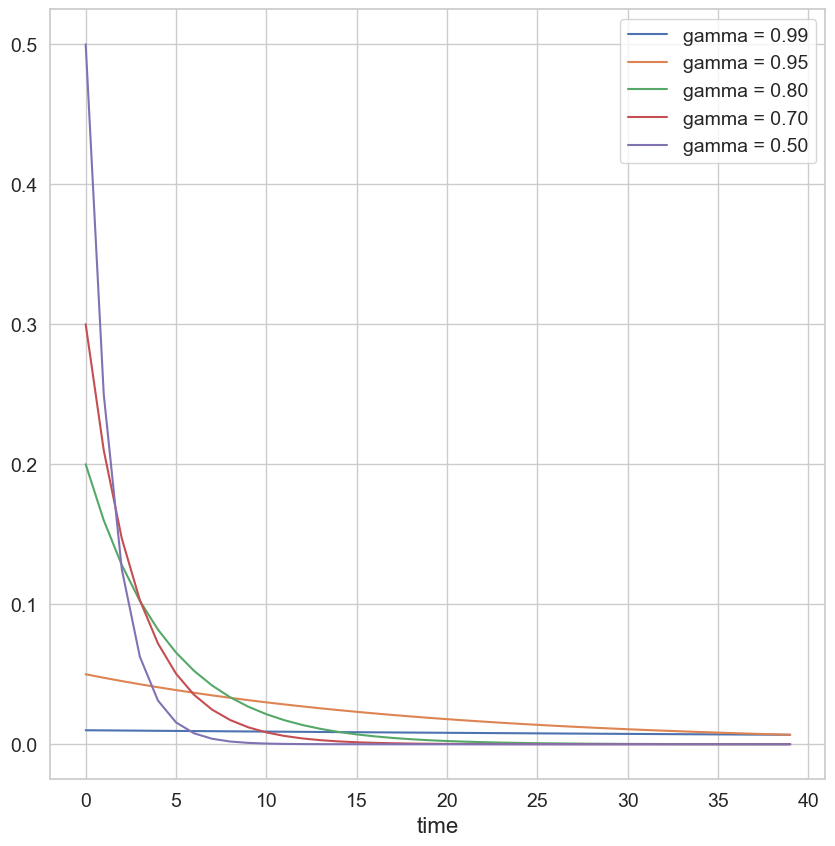

In [32]:
# Influence of \gamma on past g_t values depending on the time

gammas = [0.99, 0.95, 0.8, 0.7, 0.5]
for gamma in gammas:
    x = torch.arange(40).detach().numpy()
    plt.plot(x, (1-gamma) * gamma ** x, label=f'gamma = {gamma:.2f}')
plt.xlabel('time');
plt.legend()
plt.show()

### Adam: ADAptive Moment estimation

- Adam uses *exponential weighted moving averages* to obtain an estimate of both the momentum (RMSProp) and also the second moment (AdaGrad) of the gradient
- Given $\beta_1, \beta_2 > 0$ weighting parameters and a very small $\epsilon = 10^{-6}$



$$
\begin{split}\begin{aligned}
    \vec{v}_t & \gets  \beta_1 \vec{v}_{t-1} + (1 - \beta_1) \vec{g}_t &\quad& \text{momentum}\\
    \vec{s}_t & \gets  \beta_2 \vec{s}_{t-1} + (1 - \beta_2) \vec{g}_t^2 &\quad& \text{scaling factor}\\
\end{aligned}\end{split}
$$

- Initialization problem: setting $\vec{v}_0 = \vec{s}_0 = 0$ may cause significant bias towards smaller values
- Mitigate the issue by re-normalizing the terms in each iteration

$$
\hat{\vec{v}}_t \gets \frac{\vec{v}_t}{1 - \beta_1^t} \text{ and } \hat{\vec{s}}_t \gets \frac{\vec{s}_t}{1 - \beta_2^t}.
$$

$$
\begin{split}\begin{aligned}
    \vec{g}_t' & \gets \frac{\eta}{\sqrt{\hat{\vec{s}}_t} + \epsilon} \hat{\vec{v}}_t &\quad& \text{rescale the gradient}\\
    \vec{x}_t & \gets \vec{x}_{t-1} - \vec{g}_t'  &\quad& \text{update the parameters}
\end{aligned}\end{split}
$$

In [33]:
def sim_scaling(T, g, beta=0.999, l=0.01, w=.01, sd=None):
    s, X = 0, []
    for t in T:
        s = beta * s + (1 - beta) * g(t)**2
        if not (sd is None): l = sd(l,t)
        lr = l/(math.sqrt(s/(1 - beta**(t)))+10**-6)
        w = w - lr * g(t)
        X.append((s/(1 - beta**(t)),lr,w))
    plot_sim(T, X, g)

def plot_sim(T, X, g):
    S, L, W = zip(*X)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    l1 = ax1.plot(T, L, label=f'Scaled LR', color="orange")
    ax1.set_ylabel("Scaled LR")
    a = ax1.twinx()
    l2 = a.plot(T, S, label=f'Scaling Factor')
    a.set_ylabel("Scaling Factor")
    ax1.legend(l1+l2, [l.get_label() for l in l1+l2])
    a = ax2.twinx()
    l1 = a.plot(T, W, label=f'Weight', color="orange")
    a.set_ylabel("Weight")
    l2 = ax2.plot(T, g(T), label=f'Gradient')
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('Gradient')
    ax2.legend(l1+l2, [l.get_label() for l in l1+l2])
    fig.tight_layout()
    plt.show()

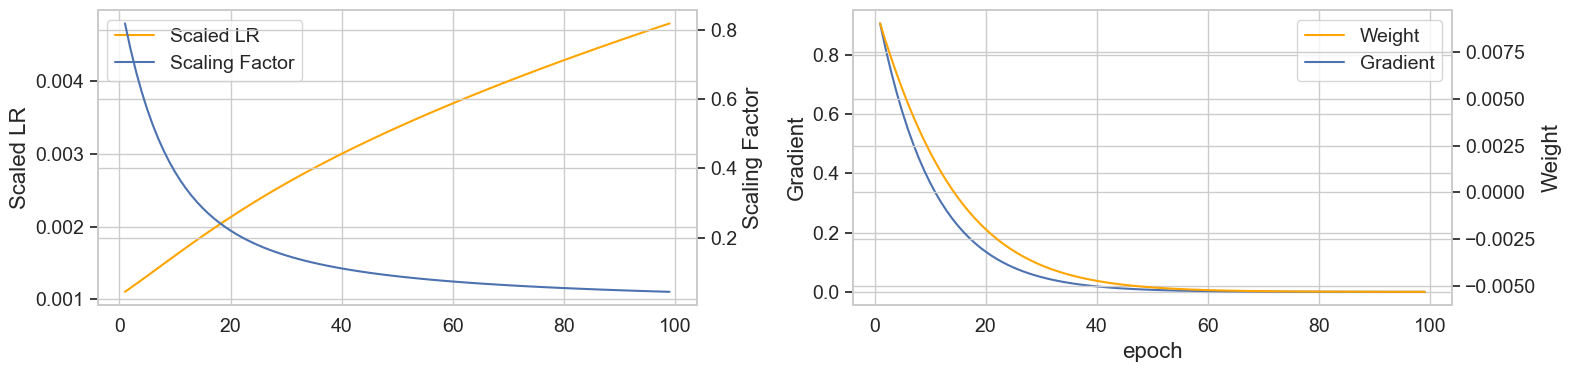

In [34]:
# Gradient simulation
g_cos = lambda x: 1*torch.cos(0.1*x)
g_exp = lambda x: 1*torch.exp(-0.1*x)

T = torch.arange(1, 100)
X = sim_scaling(T, g_exp, beta=0.999, l=0.001, w=.01)

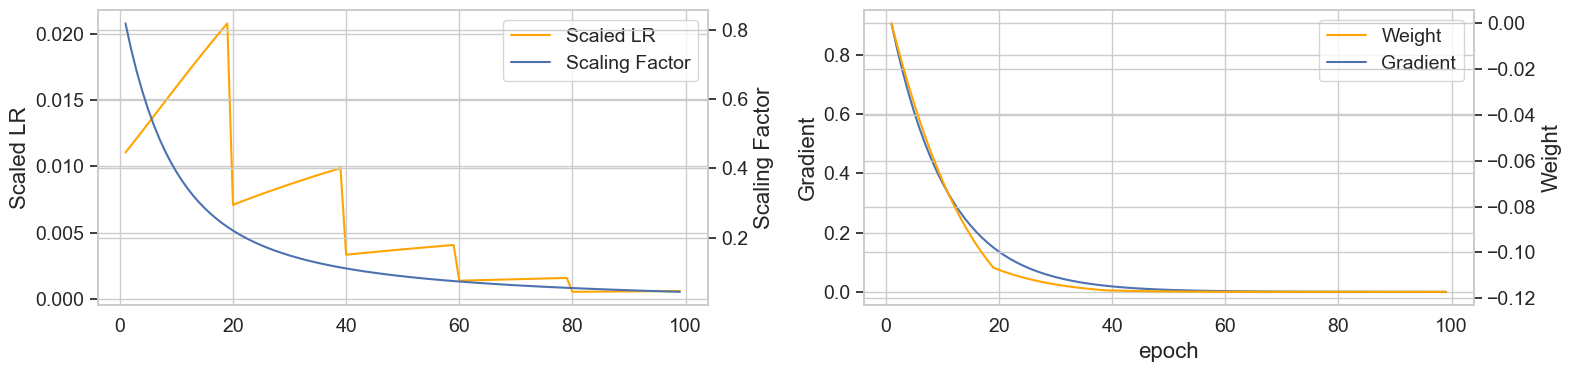

In [35]:
# Scheduler
def scheduler(l, t, s_r=3, s_t=20):
    if t % s_t != 0 : return l 
    return l / s_r

T = torch.arange(1, 100)
X = sim_scaling(T, g_exp, beta=0.999, l=0.01, w=.01, sd=scheduler)

## Schedulers



# Summary

- GD is often considered as a brute-force unprinciped method in the non-convex optimization
- Nevertheless, it works incredibly well in DL settings
- Selection of the optimization algorithm is essential:
  - Momentum and Nesterov accelerated gradient can reduce oscillations and find better step length
  - Adagrad - adapts learning rate by performing smaller or larger updates depending on the frequencies of observed features (sparse data)
  - Adadelta is a version of Adagrad that keeps track of only $k$ past gradients required for the adaptive selection of the learning rate
  - Adam - automatically adapts the moment for each parameter (similar to momentum) by tracking exponentially decaying average of $k$ past gradients